In [1]:
# ======================================================================
# FINAL FIXED Model v3 Pipeline — Multi-step FUTURE (Keras 3.x compatible)
# ======================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --------------------------
# HYPERPARAMS
# --------------------------
SEQ_LEN = 30
EMB_DIM = 32
GRU_UNITS = 256
DENSE_UNITS = 128
BATCH = 64
EPOCHS = 100
MODEL_DIR = "./models_v3"
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------------
# USER-CONTROLLED FUTURE STEPS
# --------------------------
FUTURE = 5   # 👈 default horizon (change to 1/3/10/20 as you like)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)


# ======================================================================
# Custom KL Consistency Layer  (Keras 3.x SAFE) — works over (B, T, C)
# ======================================================================
class KLConsistencyLayer(tf.keras.layers.Layer):
    def __init__(self, weight=0.5, **kwargs):
        super().__init__(**kwargs)
        self.weight = weight
        self.kld = tf.keras.losses.KLDivergence(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, inputs):
        top_out, proj_soft = inputs  # both (B, FUTURE, C)
        # KLDivergence returns (B, FUTURE); then mean over both dims
        kl = self.kld(top_out, proj_soft)
        kl = tf.reduce_mean(kl) * self.weight
        self.add_loss(kl)  # tracked by Keras
        return top_out

class SliceLayer(tf.keras.layers.Layer):
    def __init__(self, index, **kwargs):
        super().__init__(**kwargs)
        self.index = index

    def call(self, x):
        return x[:, :, self.index:self.index + 1]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"index": self.index})
        return cfg


# ======================================================================
# DATA PREPARATION — multi-step FUTURE targets
# ======================================================================
def prepare_dataset_from_df(
        df,
        seq_len=SEQ_LEN,
        input_cols_t=['Va_L2','Va_L1','PFN_Top_region','PFN_slice_4','PFN_slice_3','PFN_slice_2','PFN_slice_1','PFN_slice_0'],
        extra_emb_cols=['folio_index','mapping','lat_cluster','PID'],
        target_slices=['PFN_Top_region','PFN_slice_4','PFN_slice_3','PFN_slice_2','PFN_slice_1','PFN_slice_0'],
        future=FUTURE,
):

    encoders = {}
    def fit_encoder(col):
        vals = df[col].unique().tolist()
        enc = {v:i for i,v in enumerate(vals)}
        encoders[col] = enc
        return enc

    # encode columns
    for c in extra_emb_cols + target_slices:
        fit_encoder(c)

    df_enc = df.copy()
    for c, m in encoders.items():
        df_enc[c] = df_enc[c].map(m).astype(int)

    # class counts
    class_counts = {c: df_enc[c].nunique() for c in target_slices}

    # group by PID (you can add mapping if desired)
    groups = []
    for _, g in df_enc.sort_values("start_ns").groupby(["PID"]):
        if len(g) >= seq_len + future:
            groups.append(g.reset_index(drop=True))

    X_seq = []
    aux_pid = []
    aux_folio = []
    aux_map = []
    aux_latc = []

    y_top = []
    y_s4 = []
    y_s3 = []
    y_s2 = []
    y_s1 = []
    y_s0 = []

    for g in groups:
        for i in range(seq_len, len(g) - future + 1):
            # input window
            win = g.iloc[i-seq_len:i]
            # future window [i .. i+future-1]
            fut = g.iloc[i:i+future]
            # we keep aux as the "current time" context (single id values), not sequences
            nxt = g.iloc[i]

            X_seq.append(win[input_cols_t].values.astype("int32"))

            aux_pid.append(nxt["PID"])
            aux_folio.append(nxt["folio_index"])
            aux_map.append(nxt["mapping"])
            aux_latc.append(nxt["lat_cluster"])

            y_top.append(fut["PFN_Top_region"].values.astype("int32"))
            y_s4.append(fut["PFN_slice_4"].values.astype("int32"))
            y_s3.append(fut["PFN_slice_3"].values.astype("int32"))
            y_s2.append(fut["PFN_slice_2"].values.astype("int32"))
            y_s1.append(fut["PFN_slice_1"].values.astype("int32"))
            y_s0.append(fut["PFN_slice_0"].values.astype("int32"))

    X_seq = np.array(X_seq, dtype=np.int32)

    aux_inputs = {
        "pid_in": np.array(aux_pid, dtype=np.int32),
        "folio_in": np.array(aux_folio, dtype=np.int32),
        "map_in": np.array(aux_map, dtype=np.int32),
        "latc_in": np.array(aux_latc, dtype=np.int32),
    }

    # y tensors: (N, FUTURE)
    y = {
        "top_out": np.array(y_top, dtype=np.int32),
        "s4_out":  np.array(y_s4,  dtype=np.int32),
        "s3_out":  np.array(y_s3,  dtype=np.int32),
        "s2_out":  np.array(y_s2,  dtype=np.int32),
        "s1_out":  np.array(y_s1,  dtype=np.int32),
        "s0_out":  np.array(y_s0,  dtype=np.int32),
    }

    return X_seq, aux_inputs, y, class_counts, encoders


# ======================================================================
# MODEL V3 — Multi-step heads + FIXED KL LOSS over FUTURE
# ======================================================================
def build_model_v3(
        seq_len,
        n_seq_features,
        class_counts,
        num_pid,
        num_folio,
        num_map,
        num_latc,
        future=FUTURE,
        emb_dim=EMB_DIM,
        gru_units=GRU_UNITS,
        dense_units=DENSE_UNITS,
        dropout=0.2
):

    # ---------------------------
    # INPUTS
    # ---------------------------
    seq_input = layers.Input((seq_len, n_seq_features), dtype="int32", name="seq_input")
    pid_in   = layers.Input((), dtype="int32", name="pid_in")
    folio_in = layers.Input((), dtype="int32", name="folio_in")
    map_in   = layers.Input((), dtype="int32", name="map_in")
    latc_in  = layers.Input((), dtype="int32", name="latc_in")

    # ---------------------------
    # PER-FEATURE EMBEDDINGS  (No Lambda now)
    # ---------------------------
    embed_layers = []
    for i in range(n_seq_features):
        col = SliceLayer(i)(seq_input)   # <--- FIXED
        emb = layers.TimeDistributed(
            layers.Embedding(512, emb_dim // 2)
        )(col)
        emb = layers.Reshape((seq_len, emb_dim // 2))(emb)
        embed_layers.append(emb)

    seq_emb = layers.Concatenate()(embed_layers) if len(embed_layers) > 1 else embed_layers[0]
    seq_emb = layers.LayerNormalization()(seq_emb)
    seq_emb = layers.SpatialDropout1D(dropout)(seq_emb)

    # ---------------------------
    # BI-GRU ENCODER
    # ---------------------------
    x = layers.Bidirectional(
        layers.GRU(gru_units, return_sequences=True, dropout=dropout)
    )(seq_emb)

    x = layers.Bidirectional(
        layers.GRU(gru_units // 2, dropout=dropout)
    )(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    # ---------------------------
    # AUX EMBEDDINGS
    # ---------------------------
    pid_emb   = layers.Embedding(num_pid, emb_dim)(pid_in)
    folio_emb = layers.Embedding(num_folio, emb_dim)(folio_in)
    map_emb   = layers.Embedding(num_map, emb_dim)(map_in)
    latc_emb  = layers.Embedding(num_latc, emb_dim)(latc_in)

    aux = layers.Concatenate()([pid_emb, folio_emb, map_emb, latc_emb])
    aux = layers.Dense(dense_units // 2, activation="relu")(aux)
    aux = layers.Dropout(dropout)(aux)

    comb = layers.Concatenate()([x, aux])
    comb = layers.Dense(dense_units, activation="relu")(comb)
    comb = layers.Dropout(dropout)(comb)

    # ---------------------------
    # Helper for future heads
    # ---------------------------
    def make_future_head(base_name, class_count):
        flat = layers.Dense(class_count * future, name=f"{base_name}_flat")(comb)
        logits = layers.Reshape((future, class_count), name=f"{base_name}_logits")(flat)
        probs = layers.Activation("softmax", name=base_name)(logits)
        return logits, probs

    # OUTPUT HEADS
    top_logits, top_raw = make_future_head("top_out", class_counts['PFN_Top_region'])
    s4_logits,  s4_out  = make_future_head("s4_out",  class_counts["PFN_slice_4"])
    s3_logits,  s3_out  = make_future_head("s3_out",  class_counts["PFN_slice_3"])
    s2_logits,  s2_out  = make_future_head("s2_out",  class_counts["PFN_slice_2"])
    s1_logits,  s1_out  = make_future_head("s1_out",  class_counts["PFN_slice_1"])
    s0_logits,  s0_out  = make_future_head("s0_out",  class_counts["PFN_slice_0"])

    # ---------------------------
    # KL CONSISTENCY LOSS PROJECTION
    # ---------------------------
    slice_concat = layers.Concatenate(axis=-1)(
        [s4_logits, s3_logits, s2_logits, s1_logits, s0_logits]
    )

    proj = layers.Dense(128, activation="relu", name="kl_proj_h")(slice_concat)
    proj = layers.Dense(class_counts["PFN_Top_region"], name="kl_proj_top")(proj)
    proj_soft = layers.Activation("softmax", name="kl_proj_soft")(proj)

    top_fixed = KLConsistencyLayer(weight=0.5, name="kl_consistency")(
        [top_raw, proj_soft]
    )
    top_out = layers.Identity(name="top_out_fixed")(top_fixed)

    # ---------------------------
    # BUILD MODEL
    # ---------------------------
    model = models.Model(
        inputs=[seq_input, pid_in, folio_in, map_in, latc_in],
        outputs=[top_out, s4_out, s3_out, s2_out, s1_out, s0_out]
    )

    losses = {
        "top_out_fixed": tf.keras.losses.SparseCategoricalCrossentropy(),
        "s4_out": tf.keras.losses.SparseCategoricalCrossentropy(),
        "s3_out": tf.keras.losses.SparseCategoricalCrossentropy(),
        "s2_out": tf.keras.losses.SparseCategoricalCrossentropy(),
        "s1_out": tf.keras.losses.SparseCategoricalCrossentropy(),
        "s0_out": tf.keras.losses.SparseCategoricalCrossentropy(),
    }

    loss_weights = {
        "top_out_fixed": 1.0,
        "s4_out": 0.8,
        "s3_out": 0.6,
        "s2_out": 0.6,
        "s1_out": 0.4,
        "s0_out": 0.2,
    }

    metrics = {k: ["accuracy"] for k in losses.keys()}

    model.compile(
        optimizer=optimizer,
        loss=losses,
        loss_weights=loss_weights,
        metrics=metrics
    )

    return model

def model_fit(model, X_tr, aux_tr, y_tr, X_val, aux_val, y_val, cb, BATCH, EPOCHS):

    history = model.fit(
        {"seq_input": X_tr,
         "pid_in": aux_tr["pid_in"],
         "folio_in": aux_tr["folio_in"],
         "map_in": aux_tr["map_in"],
         "latc_in": aux_tr["latc_in"]},

        [y_tr["top_out"], y_tr["s4_out"], y_tr["s3_out"], y_tr["s2_out"], y_tr["s1_out"], y_tr["s0_out"]],

        validation_data=(
            {"seq_input": X_val,
             "pid_in": aux_val["pid_in"],
             "folio_in": aux_val["folio_in"],
             "map_in": aux_val["map_in"],
             "latc_in": aux_val["latc_in"]},

            [y_val["top_out"], y_val["s4_out"], y_val["s3_out"], y_val["s2_out"], y_val["s1_out"], y_val["s0_out"]]
        ),

        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=cb,
        verbose=2
    )
    
    return model, history


# ======================================================================
# TRAIN PIPELINE
# ======================================================================
def train_pipeline(df, model: build_model_v3 = None, model_build: bool = True,
                   BATCH: int = 64, EPOCHS: int = 200, gru_units=GRU_UNITS,
                   dense_units=DENSE_UNITS, dropout=0.2, future=FUTURE):

    X_seq, aux_inputs, y, class_counts, encoders = prepare_dataset_from_df(df, future=future)

    N, seq_len, n_feats = X_seq.shape
    print("Dataset size:", N)
    print("Sequence shape:", seq_len, n_feats)
    print("Class counts:", class_counts)
    print("Future horizon:", future)

    # split
    idx = np.arange(N)
    np.random.shuffle(idx)
    split = int(0.85*N)

    tr_idx = idx[:split]
    val_idx = idx[split:]

    X_tr = X_seq[tr_idx]
    X_val = X_seq[val_idx]

    aux_tr = {k: v[tr_idx] for k,v in aux_inputs.items()}
    aux_val = {k: v[val_idx] for k,v in aux_inputs.items()}

    y_tr = {k: v[tr_idx] for k,v in y.items()}
    y_val = {k: v[val_idx] for k,v in y.items()}

    if model_build:
        model = build_model_v3(
            seq_len=seq_len,
            n_seq_features=n_feats,
            class_counts=class_counts,
            num_pid=df["PID"].nunique(),
            num_folio=df["folio_index"].nunique(),
            num_map=df["mapping"].nunique(),
            num_latc=df["lat_cluster"].nunique(),
            future=future,
            gru_units=gru_units,
            dense_units=dense_units,
            dropout=dropout
        )

        # model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=24, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8),
        callbacks.ModelCheckpoint(f"{MODEL_DIR}/gru_slices_v3_best.keras", save_best_only=True),
    ]

    model, history = model_fit(model, X_tr, aux_tr, y_tr, X_val, aux_val, y_val, cb, BATCH, EPOCHS)

    # save meta
    import pickle
    with open(f"{MODEL_DIR}/v3_meta.pkl", "wb") as f:
        pickle.dump({"encoders": encoders, "class_counts": class_counts, "seq_len": seq_len, "future": future}, f)

    return model, history


# ======================================================================
# PFN Reconstruct from slices
# ======================================================================
def reconstruct_pfn(top, s4, s3, s2, s1, s0):
    return ((int(top) << 20) |
            (int(s4)  << 16) |
            (int(s3)  << 12) |
            (int(s2)  << 8)  |
            (int(s1)  << 4)  |
            (int(s0)))


# ======================================================================
# VALIDATION + VISUALIZATION (supports FUTURE>1)
# ======================================================================
def _flatten_future(arr_2d):
    # (N, FUTURE) -> (N*FUTURE,)
    return arr_2d.reshape(-1)

def plot_validation_results(true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
                            pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0):

    # Flatten across horizon to compute distributions
    t_top = _flatten_future(true_top); p_top = _flatten_future(pred_top)
    t_s4  = _flatten_future(true_s4);  p_s4  = _flatten_future(pred_s4)
    t_s3  = _flatten_future(true_s3);  p_s3  = _flatten_future(pred_s3)
    t_s2  = _flatten_future(true_s2);  p_s2  = _flatten_future(pred_s2)
    t_s1  = _flatten_future(true_s1);  p_s1  = _flatten_future(pred_s1)
    t_s0  = _flatten_future(true_s0);  p_s0  = _flatten_future(pred_s0)

    # PFN DIFF calculation (per (sample, step))
    true_pfn = np.array([reconstruct_pfn(a,b,c,d,e,f) for a,b,c,d,e,f in zip(t_top,t_s4,t_s3,t_s2,t_s1,t_s0)])
    pred_pfn = np.array([reconstruct_pfn(a,b,c,d,e,f) for a,b,c,d,e,f in zip(p_top,p_s4,p_s3,p_s2,p_s1,p_s0)])
    pfn_diff = np.abs(pred_pfn - true_pfn)

    # Slice Accuracy
    acc_top = np.mean(p_top == t_top)
    acc_s4  = np.mean(p_s4  == t_s4)
    acc_s3  = np.mean(p_s3  == t_s3)
    acc_s2  = np.mean(p_s2  == t_s2)
    acc_s1  = np.mean(p_s1  == t_s1)
    acc_s0  = np.mean(p_s0  == t_s0)

    slice_acc = [acc_top, acc_s4, acc_s3, acc_s2, acc_s1, acc_s0]
    slice_labels = ["Top", "S4", "S3", "S2", "S1", "S0"]

    # PLOT 1: PFN DIFF (Histogram)
    plt.figure(figsize=(10,5))
    plt.hist(pfn_diff, bins=40)
    plt.title("PFN Absolute Difference Distribution")
    plt.xlabel("ABS(TRUE - PRED)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    # PLOT 2: Slice-level Accuracy
    plt.figure(figsize=(8,5))
    plt.bar(slice_labels, slice_acc)
    plt.ylim(0, 1)
    plt.title("Slice Accuracy (All Future Steps)")
    plt.ylabel("Accuracy")
    plt.grid(True, axis='y')
    plt.show()

    # PLOT 3: PFN DIFF SCATTER
    plt.figure(figsize=(10,5))
    plt.scatter(range(len(pfn_diff)), pfn_diff, s=10)
    plt.title("PFN Difference per (Sample, Step)")
    plt.xlabel("Flattened Index")
    plt.ylabel("Absolute PFN Diff")
    plt.grid(True)
    plt.show()


def generate_pfn_error_heatmap(true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
                               pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0):

    t_top = _flatten_future(true_top); p_top = _flatten_future(pred_top)
    t_s4  = _flatten_future(true_s4);  p_s4  = _flatten_future(pred_s4)
    t_s3  = _flatten_future(true_s3);  p_s3  = _flatten_future(pred_s3)
    t_s2  = _flatten_future(true_s2);  p_s2  = _flatten_future(pred_s2)
    t_s1  = _flatten_future(true_s1);  p_s1  = _flatten_future(pred_s1)
    t_s0  = _flatten_future(true_s0);  p_s0  = _flatten_future(pred_s0)

    true_pfn = np.array([reconstruct_pfn(a,b,c,d,e,f) for a,b,c,d,e,f in zip(t_top,t_s4,t_s3,t_s2,t_s1,t_s0)])
    pred_pfn = np.array([reconstruct_pfn(a,b,c,d,e,f) for a,b,c,d,e,f in zip(p_top,p_s4,p_s3,p_s2,p_s1,p_s0)])
    abs_diff = np.abs(pred_pfn - true_pfn)

    mismatch = np.zeros((len(abs_diff), 6), dtype=int)
    mismatch[:, 0] = (t_top != p_top)
    mismatch[:, 1] = (t_s4  != p_s4)
    mismatch[:, 2] = (t_s3  != p_s3)
    mismatch[:, 3] = (t_s2  != p_s2)
    mismatch[:, 4] = (t_s1  != p_s1)
    mismatch[:, 5] = (t_s0  != p_s0)

    slice_labels = ["TOP", "S4", "S3", "S2", "S1", "S0"]

    corr = np.zeros(6)
    for i in range(6):
        if mismatch[:, i].sum() > 0:
            corr[i] = np.mean(abs_diff[mismatch[:, i] == 1])
        else:
            corr[i] = 0.0

    corr_norm = corr / (np.max(corr) + 1e-9)

    plt.figure(figsize=(7, 4))
    sns.heatmap(corr_norm.reshape(1, -1), annot=True, cmap="magma",
                xticklabels=slice_labels, yticklabels=["PFN Error Impact"],
                cbar=True)

    plt.title("PFN Error Heatmap (Slice Contribution Strength)")
    plt.show()

    print("\nRaw Mean PFN Error per Slice Mismatch:")
    for lbl, val in zip(slice_labels, corr):
        print(f"{lbl}: {val:.2f}")


def plot_slice_confusion(true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
                         pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0):

    # Flatten across FUTURE for confusion matrices
    slice_names = ["TOP", "S4", "S3", "S2", "S1", "S0"]
    true_slices = [_flatten_future(true_top), _flatten_future(true_s4), _flatten_future(true_s3),
                   _flatten_future(true_s2), _flatten_future(true_s1), _flatten_future(true_s0)]
    pred_slices = [_flatten_future(pred_top), _flatten_future(pred_s4), _flatten_future(pred_s3),
                   _flatten_future(pred_s2), _flatten_future(pred_s1), _flatten_future(pred_s0)]

    plt.figure(figsize=(16, 20))
    for idx, (name, t, p) in enumerate(zip(slice_names, true_slices, pred_slices)):
        cm = confusion_matrix(t, p)
        plt.subplot(3, 2, idx+1)
        sns.heatmap(cm, cmap="viridis", annot=False, cbar=True)
        plt.title(f"Confusion Matrix – {name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def print_classification_reports(true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
                                 pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0):

    slice_names = ["TOP", "S4", "S3", "S2", "S1", "S0"]
    true_slices = [_flatten_future(true_top), _flatten_future(true_s4), _flatten_future(true_s3),
                   _flatten_future(true_s2), _flatten_future(true_s1), _flatten_future(true_s0)]
    pred_slices = [_flatten_future(pred_top), _flatten_future(pred_s4), _flatten_future(pred_s3),
                   _flatten_future(pred_s2), _flatten_future(pred_s1), _flatten_future(pred_s0)]

    for name, t, p in zip(slice_names, true_slices, pred_slices):
        print("\n====================================")
        print(f"  Classification Report — {name}")
        print("====================================")
        labels = sorted(np.unique(np.concatenate([t, p])))
        print(classification_report(t, p, labels=labels, digits=3))


def validate_model(model, X_val, aux_val, y_val, max_samples=5, max_steps_preview=3):

    print("\n======================")
    print(" RUNNING VALIDATION ")
    print("======================")

    preds = model.predict(
        {
            "seq_input": X_val,
            "pid_in": aux_val["pid_in"],
            "folio_in": aux_val["folio_in"],
            "map_in": aux_val["map_in"],
            "latc_in": aux_val["latc_in"]
        },
        batch_size=128,
        verbose=1
    )

    # unpack predictions: (N, FUTURE, C) -> argmax -> (N, FUTURE)
    pred_top = np.argmax(preds[0], axis=2)
    pred_s4  = np.argmax(preds[1], axis=2)
    pred_s3  = np.argmax(preds[2], axis=2)
    pred_s2  = np.argmax(preds[3], axis=2)
    pred_s1  = np.argmax(preds[4], axis=2)
    pred_s0  = np.argmax(preds[5], axis=2)

    # ground truth (N, FUTURE)
    true_top = y_val["top_out"]
    true_s4  = y_val["s4_out"]
    true_s3  = y_val["s3_out"]
    true_s2  = y_val["s2_out"]
    true_s1  = y_val["s1_out"]
    true_s0  = y_val["s0_out"]

    N = len(pred_top)
    steps = true_top.shape[1]

    for i in range(min(N, max_samples)):
        print("\n-----------------------------")
        print(f"SAMPLE #{i}")
        show_steps = min(steps, max_steps_preview)
        for t in range(show_steps):
            print(f"  step {t}:")
            print("    TRUE slices: ",
                  int(true_top[i, t]), int(true_s4[i, t]), int(true_s3[i, t]),
                  int(true_s2[i, t]), int(true_s1[i, t]), int(true_s0[i, t]))
            print("    PRED slices: ",
                  int(pred_top[i, t]), int(pred_s4[i, t]), int(pred_s3[i, t]),
                  int(pred_s2[i, t]), int(pred_s1[i, t]), int(pred_s0[i, t]))

            # PFN reconstruct
            true_pfn = reconstruct_pfn(true_top[i, t], true_s4[i, t], true_s3[i, t],
                                       true_s2[i, t], true_s1[i, t], true_s0[i, t])
            pred_pfn = reconstruct_pfn(pred_top[i, t], pred_s4[i, t], pred_s3[i, t],
                                       pred_s2[i, t], pred_s1[i, t], pred_s0[i, t])

            diff = pred_pfn - true_pfn
            print("    TRUE PFN:", true_pfn, "| PRED PFN:", pred_pfn,
                  "| DIFF:", diff, "| HEX:", hex(abs(diff)))

    print("\n========== DONE ==========\n")

    plot_validation_results(
        true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
        pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0
    )

    generate_pfn_error_heatmap(
        true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
        pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0
    )

    plot_slice_confusion(
        true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
        pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0
    )

    print_classification_reports(
        true_top, true_s4, true_s3, true_s2, true_s1, true_s0,
        pred_top, pred_s4, pred_s3, pred_s2, pred_s1, pred_s0
    )


In [ ]:
CSV_PATH="../_filter/filter_Swap_log.csv"
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
else:
    # try to use df variable (if notebook already has it)
    try:
        df
    except NameError:
        raise FileNotFoundError(f"CSV not found at {CSV_PATH} and `df` not defined in namespace.")

* @used to load save model   ⬇️⬇️⬇️ 
----

In [ ]:
from tensorflow import keras

# from your_file import KLConsistencyLayer  # import your layer
model1 = keras.models.load_model(
    "./models_v3/gru_slices_v3_best.keras",
    custom_objects={"KLConsistencyLayer": KLConsistencyLayer,"SliceLayer": SliceLayer},
    safe_mode=False
)
model1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 30, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer         │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_1       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_2       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_3       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_4       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_5       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_6       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_layer_7       │ (None, 30, 1)     │          0 │ seq_input[0][0]   │
│ (SliceLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 30, 1, 16) │      8,192 │ slice_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 30, 1, 16) │      8,192 │ slice_layer_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 30, 1, 16) │      8,192 │ slice_layer_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 30, 1, 16) │      8,192 │ slice_layer_3[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 30, 1, 16) │      8,192 │ slice_layer_4[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_13 │ (None, 30, 1, 16) │      8,192 │ slice_layer_5[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_14 │ (None, 30, 1, 16) │      8,192 │ slice_layer_6[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_15 │ (None, 30, 1, 16) │      8,192 │ slice_layer_7[0]

 Total params: 1,416,824 (5.40 MB)

 Trainable params: 472,274 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 944,550 (3.60 MB)

In [ ]:
#uncomment when you used Save model 
# model, history = train_pipeline(df, model , False, BATCH=32, EPOCHS=100, gru_units=128, dense_units=64, dropout=0.1)

#else used it Default.
model, history = train_pipeline(df, BATCH=32, EPOCHS=100, gru_units=128, dense_units=64, dropout=0.1)

Dataset size: 4630
Sequence shape: 30 8
Class counts: {'PFN_Top_region': 2, 'PFN_slice_4': 14, 'PFN_slice_3': 16, 'PFN_slice_2': 16, 'PFN_slice_1': 16, 'PFN_slice_0': 16}
Future horizon: 5
Epoch 1/100
123/123 - 10s - 84ms/step - loss: 4.2398 - s0_out_accuracy: 0.1702 - s1_out_accuracy: 0.3749 - s2_out_accuracy: 0.4561 - s3_out_accuracy: 0.4739 - s4_out_accuracy: 0.6310 - top_out_fixed_accuracy: 0.9277 - val_loss: 3.7903 - val_s0_out_accuracy: 0.1787 - val_s1_out_accuracy: 0.4181 - val_s2_out_accuracy: 0.5145 - val_s3_out_accuracy: 0.5499 - val_s4_out_accuracy: 0.6679 - val_top_out_fixed_accuracy: 0.9407 - learning_rate: 0.0010
Epoch 2/100
123/123 - 10s - 81ms/step - loss: 4.2151 - s0_out_accuracy: 0.1735 - s1_out_accuracy: 0.3695 - s2_out_accuracy: 0.4549 - s3_out_accuracy: 0.4780 - s4_out_accuracy: 0.6319 - top_out_fixed_accuracy: 0.9301 - val_loss: 3.8152 - val_s0_out_accuracy: 0.1721 - val_s1_out_accuracy: 0.4181 - val_s2_out_accuracy: 0.5076 - val_s3_out_accuracy: 0.5433 - val_s4_o

Dataset size: 4630
Sequence shape: 30 8
Class counts: {'PFN_Top_region': 2, 'PFN_slice_4': 14, 'PFN_slice_3': 16, 'PFN_slice_2': 16, 'PFN_slice_1': 16, 'PFN_slice_0': 16}

 RUNNING VALIDATION 
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step

-----------------------------
SAMPLE #0
  step 0:
    TRUE slices:  0 7 6 11 2 8
    PRED slices:  0 7 6 11 2 8
    TRUE PFN: 486184 | PRED PFN: 486184 | DIFF: 0 | HEX: 0x0
  step 1:
    TRUE slices:  0 7 6 11 2 9
    PRED slices:  0 7 6 11 2 8
    TRUE PFN: 486185 | PRED PFN: 486184 | DIFF: -1 | HEX: 0x1
  step 2:
    TRUE slices:  0 7 6 11 2 13
    PRED slices:  0 7 6 11 2 5
    TRUE PFN: 486189 | PRED PFN: 486181 | DIFF: -8 | HEX: 0x8

-----------------------------
SAMPLE #1
  step 0:
    TRUE slices:  1 12 3 0 6 6
    PRED slices:  1 12 14 15 5 1
    TRUE PFN: 1847398 | PRED PFN: 1896273 | DIFF: 48875 | HEX: 0xbeeb
  step 1:
    TRUE slices:  0 0 4 5 8 15
    PRED slices:  0 12 8 0 5 7
    TRUE PFN: 17807 | PRED PFN: 819287 | DIFF: 801480 | HEX: 0xc3ac

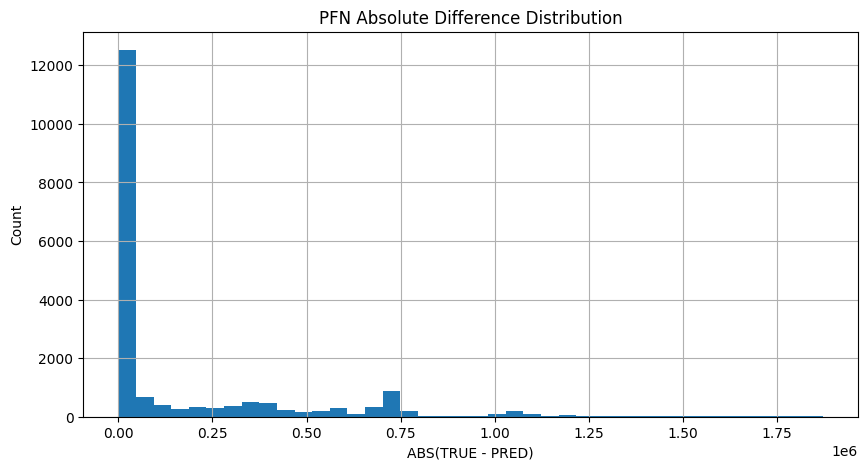

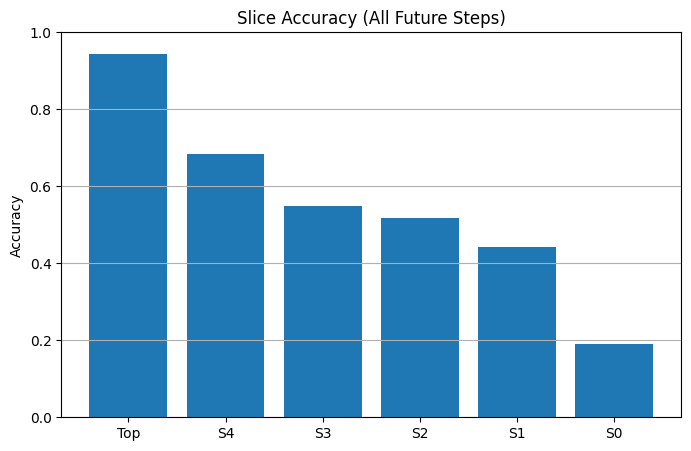

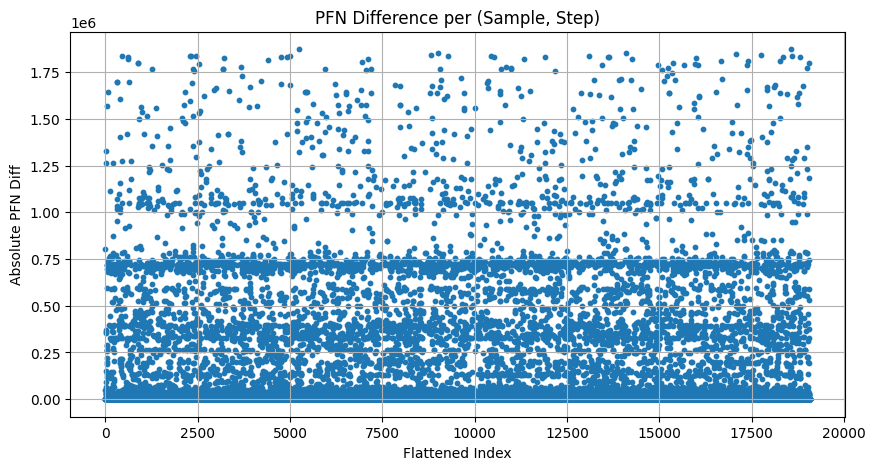

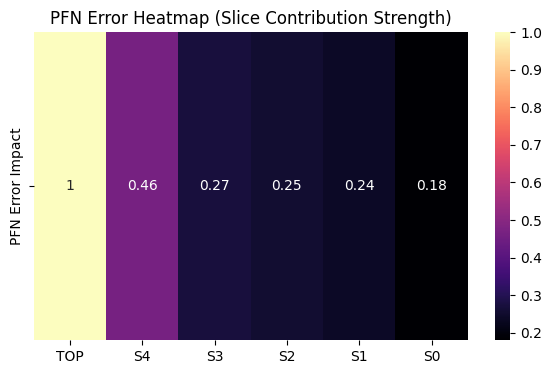


Raw Mean PFN Error per Slice Mismatch:
TOP: 1091794.73
S4: 504285.74
S3: 294327.53
S2: 277204.23
S1: 260045.60
S0: 196328.94


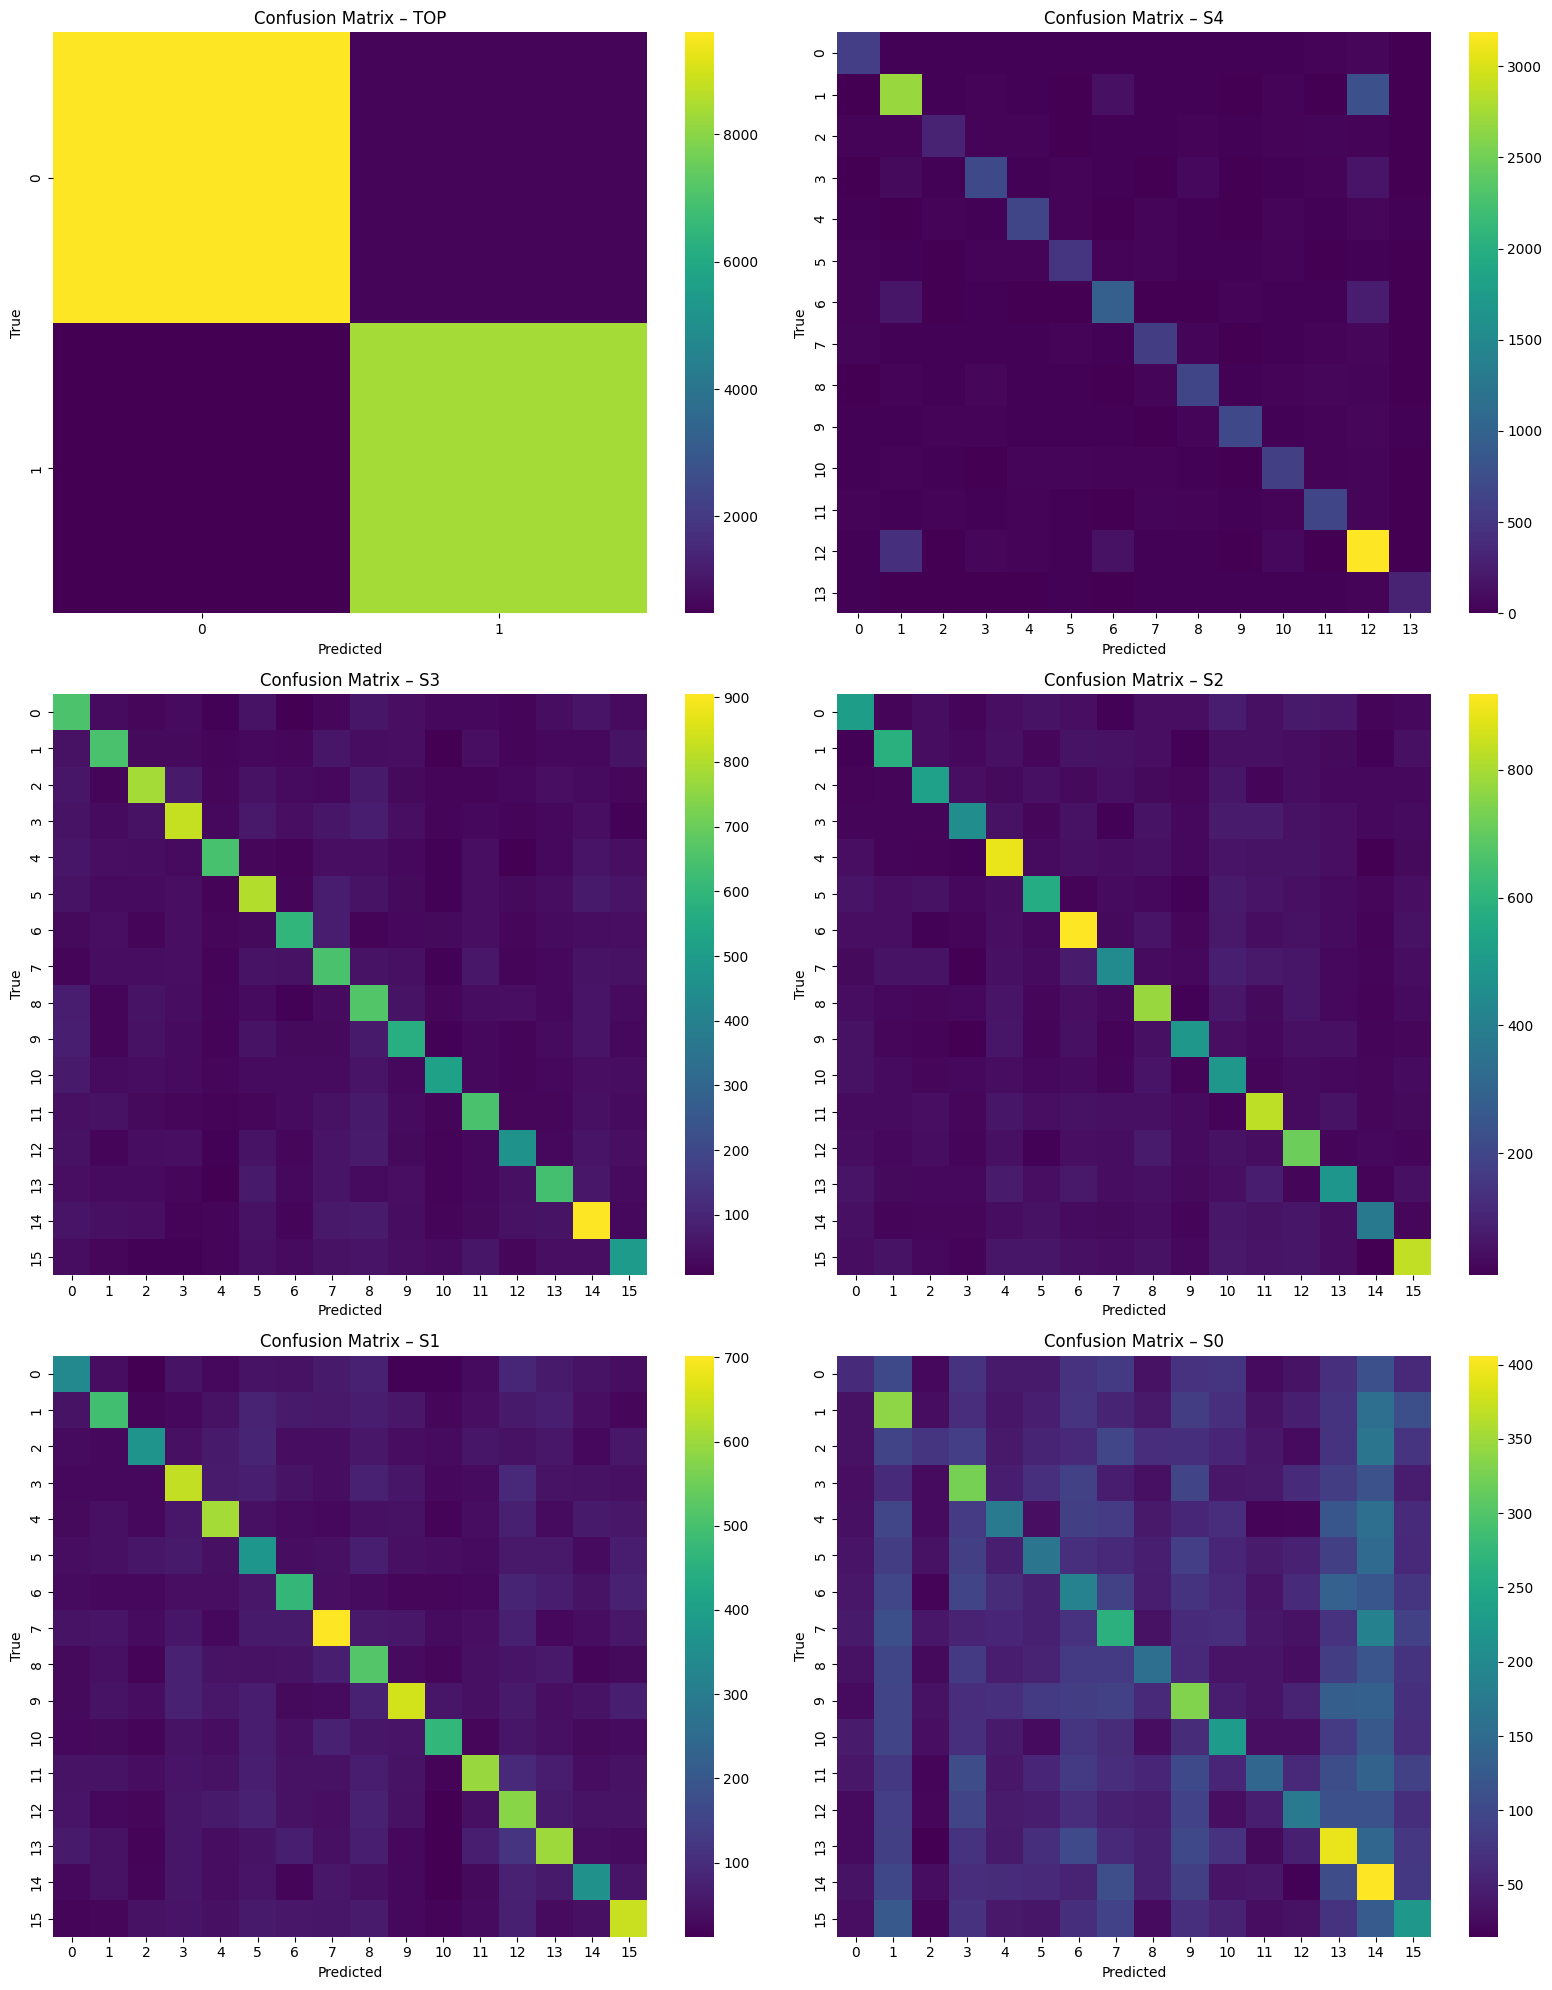


  Classification Report — TOP
              precision    recall  f1-score   support

           0      0.953     0.939     0.946     10222
           1      0.931     0.946     0.939      8853

    accuracy                          0.942     19075
   macro avg      0.942     0.943     0.942     19075
weighted avg      0.943     0.942     0.943     19075


  Classification Report — S4
              precision    recall  f1-score   support

           0      0.672     0.665     0.668       865
           1      0.750     0.714     0.732      3772
           2      0.568     0.478     0.519       648
           3      0.681     0.588     0.631      1197
           4      0.701     0.681     0.691       957
           5      0.641     0.631     0.636       772
           6      0.671     0.625     0.647      1527
           7      0.650     0.627     0.639       893
           8      0.636     0.646     0.641      1014
           9      0.804     0.681     0.737      1022
          10     

In [ ]:
X_seq, aux_inputs, y, class_counts, encoders = prepare_dataset_from_df(df)

N, seq_len, n_feats = X_seq.shape
print("Dataset size:", N)
print("Sequence shape:", seq_len, n_feats)
print("Class counts:", class_counts)

# split
idx = np.arange(N)
np.random.shuffle(idx)
split = int(0.824*N)

tr_idx = idx[:split]
val_idx = idx[split:]

X_tr = X_seq[tr_idx]
X_val = X_seq[val_idx]

aux_tr = {k: v[tr_idx] for k,v in aux_inputs.items()}
aux_val = {k: v[val_idx] for k,v in aux_inputs.items()}

y_tr = {k: v[tr_idx] for k,v in y.items()}
y_val = {k: v[val_idx] for k,v in y.items()}

validate_model(model1, X_tr, aux_tr, y_tr,max_samples=50) #add model that you test

    ====================================
    Classification Report — TOP
    ====================================
                precision    recall  f1-score   support

            0      0.985     0.958     0.971       804
            1      0.978     0.992     0.985      1493

        accuracy                          0.980      2297
    macro avg      0.981     0.975     0.978      2297
    weighted avg      0.980     0.980     0.980      2297


    ====================================
    Classification Report — S4
    ====================================
                precision    recall  f1-score   support

            0      0.750     0.500     0.600        48
            1      0.815     0.837     0.826       662
            2      0.684     0.342     0.456        38
            3      0.705     0.478     0.570        90
            4      0.662     0.831     0.737        59
            5      0.833     0.614     0.707        57
            6      0.819     0.785     0.802       270
            7      0.667     0.261     0.375        46
            8      0.811     0.600     0.690        50
            9      0.901     0.906     0.904       171
            10      0.745     0.874     0.805       629
            11      0.692     0.474     0.562        38
            12      0.757     0.667     0.709        42
            13      0.765     0.804     0.784        97

        accuracy                          0.784      2297
    macro avg      0.758     0.641     0.680      2297
    weighted avg      0.783     0.784     0.777      2297


    ====================================
    Classification Report — S3
    ====================================
                precision    recall  f1-score   support

            0      0.531     0.531     0.531       147
            1      0.603     0.538     0.569       130
            2      0.538     0.474     0.504       133
            3      0.581     0.649     0.613       154
            4      0.674     0.576     0.621       151
            5      0.536     0.646     0.585       175
            6      0.561     0.330     0.416        97
            7      0.531     0.559     0.544       170
            8      0.544     0.514     0.529       144
            9      0.573     0.492     0.529       120
            10      0.547     0.406     0.466       101
            11      0.657     0.661     0.659       174
            12      0.488     0.580     0.530       143
            13      0.485     0.600     0.536       135
            14      0.584     0.620     0.601       208
            15      0.426     0.452     0.439       115

        accuracy                          0.554      2297
    macro avg      0.554     0.539     0.542      2297
    weighted avg      0.557     0.554     0.552      2297


    ====================================
    Classification Report — S2
    ====================================
                precision    recall  f1-score   support

            0      0.383     0.279     0.323       147
            1      0.435     0.368     0.398       136
            2      0.432     0.398     0.415       128
            3      0.493     0.289     0.365       121
            4      0.424     0.585     0.492       176
            5      0.500     0.474     0.487       154
            6      0.381     0.387     0.384       137
            7      0.446     0.500     0.471       156
            8      0.362     0.402     0.381       127
            9      0.625     0.409     0.495       110
            10      0.458     0.519     0.486       187
            11      0.419     0.292     0.344       106
            12      0.476     0.533     0.503       169
            13      0.305     0.459     0.367       135
            14      0.403     0.269     0.322       108
            15      0.541     0.595     0.567       200

        accuracy                          0.439      2297
    macro avg      0.443     0.422     0.425      2297
    weighted avg      0.445     0.439     0.435      2297


    ====================================
    Classification Report — S1
    ====================================
                precision    recall  f1-score   support

            0      0.419     0.383     0.400       115
            1      0.407     0.517     0.455       143
            2      0.479     0.436     0.457       133
            3      0.338     0.322     0.330       152
            4      0.480     0.500     0.490       172
            5      0.443     0.352     0.393       122
            6      0.337     0.242     0.282       132
            7      0.420     0.472     0.444       161
            8      0.481     0.414     0.445       157
            9      0.371     0.413     0.391       167
            10      0.538     0.415     0.469       118
            11      0.340     0.325     0.332       163
            12      0.308     0.331     0.319       148
            13      0.356     0.383     0.369       149
            14      0.328     0.381     0.352       113
            15      0.385     0.441     0.411       152

        accuracy                          0.398      2297
    macro avg      0.402     0.396     0.396      2297
    weighted avg      0.401     0.398     0.397      2297


    ====================================
    Classification Report — S0
    ====================================
                precision    recall  f1-score   support

            0      0.353     0.058     0.100       103
            1      0.247     0.304     0.273       161
            2      0.226     0.099     0.138       121
            3      0.310     0.320     0.315       150
            4      0.190     0.237     0.211       160
            5      0.295     0.177     0.221       130
            6      0.197     0.265     0.226       162
            7      0.231     0.267     0.248       150
            8      0.240     0.186     0.210       129
            9      0.304     0.344     0.323       151
            10      0.281     0.187     0.224       134
            11      0.310     0.248     0.276       125
            12      0.233     0.242     0.237       157
            13      0.262     0.367     0.305       169
            14      0.177     0.265     0.213       166
            15      0.268     0.202     0.230       129

        accuracy                          0.244      2297
    macro avg      0.258     0.236     0.234      2297
    weighted avg      0.254     0.244     0.239      2297